# Experimento LightGBM (local)

Este notebook asume que `dvc pull` ya trajo los `jobs_*.csv` a `data/raw/foorilla/`.

## 1. Configuración de la sesión (local)

In [1]:
import os
from pathlib import Path

FAST_MODE = False
REPO_DIR = Path.cwd()
while not (REPO_DIR / "ml").exists() and REPO_DIR != REPO_DIR.parent:
    REPO_DIR = REPO_DIR.parent
DATA_DIR = REPO_DIR / "data/raw/foorilla"
RUN_NAME = "local-lightgbm-reported-base"

assert (REPO_DIR / "ml").exists(), "No se encontró la carpeta ml/ subiendo desde el cwd; ajusta REPO_DIR manualmente."
# Alinea el cwd del kernel con la raíz del repo -- es donde siempre se ejecuta
# la CLI (`python -m ml.lightgbm_baseline.run`), así que rutas relativas
# (en particular el "./mlruns" por defecto de MLflow cuando no se fija un
# artifact_location absoluto) resuelven al mismo lugar sin importar si el
# entrenamiento vino del notebook o de la CLI.
os.chdir(REPO_DIR)
print("Repo:", REPO_DIR)
print("Modo rápido. Fast mode =" if FAST_MODE else "Reproducción completa. Fast mode =", FAST_MODE)


Repo: /Users/alejandra/AI-UniAndes/PDS_2026_14/Microproyecto
Reproducción completa. Fast mode = False


## 2. Datos

Aquí los CSV ya están en disco tras correr `dvc pull` desde la terminal

In [2]:
import sys
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

csv_files = sorted(DATA_DIR.glob("jobs_*.csv"))
assert csv_files, (
    f"No se encontraron jobs_*.csv en {DATA_DIR}. "
    "Corre 'dvc pull' desde la raíz del repositorio."
)
[(path.name, round(path.stat().st_size / 1_000_000, 2)) for path in csv_files]


[('jobs_2026-08-16.csv', 395.38),
 ('jobs_2026-08-20.csv', 3.63),
 ('jobs_2026-08-24.csv', 1.91),
 ('jobs_2026-08-28.csv', 2.63),
 ('jobs_2026-09-01.csv', 1.54)]

## 3. Importaciones y parámetros del experimento

In [3]:
import json
from datetime import datetime, timezone

import lightgbm as lgb
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import yaml
from IPython.display import display

from ml.catboost_baseline.data import load_raw_data, prepare_model_data, select_experiment, temporal_split
from ml.catboost_baseline.evaluation import reconstruct_targets, regression_metrics, segment_metrics, training_targets
from ml.catboost_baseline.features import build_features
from ml.lightgbm_baseline.model import feature_importance_frame, to_lightgbm_frame, train_model

with (REPO_DIR / "ml/lightgbm_baseline/params.yaml").open(encoding="utf-8") as handle:
    config = yaml.safe_load(handle)
config.setdefault("evaluation", {}).setdefault("company_generalization", {"enabled": True, "minimum_size": 30})

MAX_ROWS_PER_FILE = 10_000 if FAST_MODE else None
N_ESTIMATORS = 100 if FAST_MODE else int(config["model"]["n_estimators"])
# Notebook equivalent of run.py's --no-company-generalization / evaluation.company_generalization.enabled.
# Flip this to False to skip section 10 without touching params.yaml.
RUN_COMPANY_GENERALIZATION = bool(config["evaluation"]["company_generalization"].get("enabled", True))
COMPANY_GENERALIZATION_MIN_SIZE = int(config["evaluation"]["company_generalization"].get("minimum_size", 30))
print({
    "max_rows_per_file": MAX_ROWS_PER_FILE, "n_estimators": N_ESTIMATORS, "experiment": config["data"]["experiment"],
    "run_company_generalization": RUN_COMPANY_GENERALIZATION,
})


{'max_rows_per_file': None, 'n_estimators': 500, 'experiment': 'reported', 'run_company_generalization': True}


## 4. Carga, deduplicación y controles de calidad

Mismas reglas que el EDA y el baseline de CatBoost: se conserva la versión más
reciente de cada `id`, se eliminan republicaciones, rangos incompletos / no
positivos / desordenados, y extremos lejanos (cerca de Tukey sobre el log del
punto medio).

In [4]:
raw = load_raw_data(csv_files, max_rows_per_file=MAX_ROWS_PER_FILE)
prepared = prepare_model_data(raw, outlier_iqr_multiplier=float(config["data"]["outlier_iqr_multiplier"]))
display(pd.Series(prepared.audit, name="valor").to_frame())


,valor
source_rows,333773
unique_ids,333422
duplicate_ids_removed,351
unique_vacancies,283551
republications_removed,49871
incomplete_targets,23353
non_positive_targets,5
unordered_targets,11
far_outliers_removed,25
outlier_lower_usd,400.894106


## 5. Muestra reportada y separación temporal

In [5]:
frame = select_experiment(prepared.frame, config["data"]["experiment"])
split, cutoffs = temporal_split(
    frame,
    train_fraction=float(config["data"]["train_fraction"]),
    validation_fraction=float(config["data"]["validation_fraction"]),
    cutoffs_from=prepared.frame,
)
usable = split.ne("excluded_missing_date")
frame, split = frame.loc[usable].copy(), split.loc[usable]
display(split.value_counts().rename("filas").to_frame())
display(pd.Series(cutoffs, name="fecha").to_frame())


,filas
train,39862
test,7573
validation,6928


,fecha
train_cutoff,2026-03-13T00:00:00+00:00
validation_cutoff,2026-06-02T00:00:00+00:00


## 6. Ingeniería de variables

`to_lightgbm_frame` convierte las columnas categóricas a dtype `category` con
los niveles fijados sobre el frame completo, **antes** de partir en
train/validation/test, para que las tres particiones compartan la misma
codificación.

In [6]:
features, categorical_features, metadata = build_features(
    frame,
    include_company=bool(config["features"]["include_company"]),
)
features = to_lightgbm_frame(features, categorical_features)
print(f"{features.shape[0]:,} filas x {features.shape[1]} variables")
print("Categóricas:", categorical_features)
display(features.head(3))


54,363 filas x 54 variables
Categóricas: ['experience_level', 'work_modality', 'primary_country', 'role_family', 'company']


,experience_level,experience_years,experience_years_missing,work_modality,primary_country,country_count,ambiguous_country,role_family,company_is_agency,publication_year,...,tool_tableau,tool_tensorflow,topic_data_engineering,topic_big_data,topic_finance_fintech,topic_mlops,topic_software_engineering_development,topic_data_science,topic_artificial_intelligence,topic_machine_learning
73069,SE,8.0,0,Remoto,United States,1,0,Data Engineer,0,2026.0,...,0,0,1,1,0,0,0,0,0,0
36015,SE,4.0,0,Presencial,United States,1,0,Data/BI Analyst,0,2026.0,...,0,0,1,1,0,0,0,0,0,0
21053,SE,7.0,0,Presencial,United States,1,0,Data Architect,0,2026.0,...,0,0,1,1,0,0,0,0,0,0


## 7. Entrenamiento de LightGBM

Igual que CatBoost: el primer modelo predice `log1p(mínimo)` y el segundo
`log1p(amplitud)`; la reconstrucción garantiza `máximo >= mínimo`.

In [7]:
train_mask = split.eq("train")
validation_mask = split.eq("validation")
test_mask = split.eq("test")
strategy = config["features"]["target_strategy"]

train_first, train_second, target_names = training_targets(
    metadata.loc[train_mask, "y_min_usd"], metadata.loc[train_mask, "y_max_usd"], strategy
)
val_first, val_second, _ = training_targets(
    metadata.loc[validation_mask, "y_min_usd"], metadata.loc[validation_mask, "y_max_usd"], strategy
)

params = dict(config["model"])
params.update(n_estimators=N_ESTIMATORS)

minimum_model = train_model(
    params, features.loc[train_mask], train_first, features.loc[validation_mask], val_first, categorical_features
)
width_model = train_model(
    params, features.loc[train_mask], train_second, features.loc[validation_mask], val_second, categorical_features
)
print("best_iteration (minimo):", minimum_model.best_iteration_)
print("best_iteration (amplitud):", width_model.best_iteration_)


best_iteration (minimo): 500
best_iteration (amplitud): 500


## 8. Métricas y comparación contra la mediana

In [8]:
def predict(mask):
    return reconstruct_targets(minimum_model.predict(features.loc[mask]), width_model.predict(features.loc[mask]), strategy)

val_predictions = predict(validation_mask)
test_predictions = predict(test_mask)
val_metrics = regression_metrics(metadata.loc[validation_mask, "y_min_usd"], metadata.loc[validation_mask, "y_max_usd"], *val_predictions)
test_metrics = regression_metrics(metadata.loc[test_mask, "y_min_usd"], metadata.loc[test_mask, "y_max_usd"], *test_predictions)

dummy_min = np.full(test_mask.sum(), metadata.loc[train_mask, "y_min_usd"].median())
dummy_max = np.full(test_mask.sum(), metadata.loc[train_mask, "y_max_usd"].median())
dummy_metrics = regression_metrics(metadata.loc[test_mask, "y_min_usd"], metadata.loc[test_mask, "y_max_usd"], dummy_min, dummy_max)

metrics_table = pd.DataFrame({"LightGBM validación": val_metrics, "LightGBM prueba": test_metrics, "Mediana ingenua": dummy_metrics}).T
display(metrics_table.round(3))
improvement_val  = 100 * (dummy_metrics["mae_mean_usd"] - val_metrics["mae_mean_usd"]) / dummy_metrics["mae_mean_usd"]
improvement_test = 100 * (dummy_metrics["mae_mean_usd"] - test_metrics["mae_mean_usd"]) / dummy_metrics["mae_mean_usd"]
print(f"Mejora (validación) frente a mediana ingenua: {improvement_val:.1f}%")
print(f"Mejora (prueba) frente a mediana ingenua: {improvement_test:.1f}%")


,mae_y1_usd,mae_y2_usd,mae_mean_usd,rmse_y1_usd,rmse_y2_usd,r2_y1,r2_y2,mae_width_usd,raw_crossing_rate,midpoint_coverage,mean_interval_iou
LightGBM validación,22821.748,31644.824,27233.286,36999.277,52554.259,0.616,0.670,19269.217,0.0,0.629,0.437
LightGBM prueba,25229.828,35231.961,30230.895,43122.724,57943.717,0.514,0.574,20185.003,0.0,0.542,0.391
Mediana ingenua,43701.545,65991.245,54846.395,61958.376,88940.444,-0.002,-0.004,34943.539,0.0,0.401,0.251


Mejora (validación) frente a mediana ingenua: 50.3%
Mejora (prueba) frente a mediana ingenua: 44.9%


## 9. Importancia de variables y segmentos

In [9]:
importance = feature_importance_frame(minimum_model, width_model, list(features.columns), target_names[1])
display(importance.head(15).round(1))

,feature,importance_minimum,importance_log_width,importance_mean
0,company,421244.2,537750.0,479497.1
1,experience_years,145161.3,117824.3,131492.8
2,publication_month,84828.0,97578.3,91203.1
3,role_family,58150.2,35823.3,46986.7
4,experience_level,32560.2,20034.1,26297.2
5,primary_country,25775.1,21963.5,23869.3
6,publication_year,20356.3,25919.4,23137.9
7,work_modality,18421.5,20944.9,19683.2
8,topic_data_engineering,12445.0,23299.2,17872.1
9,knowledge_deep_learning,10167.9,20936.1,15552.0


In [10]:
# Val
segments = pd.DataFrame(segment_metrics(metadata.loc[validation_mask], val_predictions[0], val_predictions[1], minimum_size=100))

print("Resultados por segmento en conjunto de validación")
display(segments.sort_values("mae_mean_usd", ascending=False).head(15).round(2))


Resultados por segmento en conjunto de validación


,segment,value,rows,mae_y1_usd,mae_y2_usd,mae_mean_usd,mae_width_usd
2,experience_level,EX,147,36397.80,42251.25,39324.53,21622.10
6,primary_country,Sin información,145,28957.10,41274.17,35115.63,22168.32
13,role_family,Otra familia,2495,27519.15,38064.28,32791.72,21156.47
1,experience_level,EN,388,21863.70,36371.74,29117.72,20030.64
7,primary_country,United States,5715,22967.48,32423.74,27695.61,19845.57
12,role_family,ML Engineer,532,21427.92,33907.64,27667.78,24808.46
0,target_source,Reportado,6928,22821.75,31644.82,27233.29,19269.22
3,experience_level,MI,2221,23102.68,31089.67,27096.18,20701.34
4,experience_level,SE,4157,22294.40,31120.49,26707.45,18364.15
8,role_family,AI Engineer,1423,20903.51,28495.83,24699.67,16688.94


In [11]:
# Test
segments = pd.DataFrame(segment_metrics(metadata.loc[test_mask], test_predictions[0], test_predictions[1], minimum_size=100))

print("Resultados por segmento en conjunto de prueba")
display(segments.sort_values("mae_mean_usd", ascending=False).head(15).round(2))


Resultados por segmento en conjunto de prueba


,segment,value,rows,mae_y1_usd,mae_y2_usd,mae_mean_usd,mae_width_usd
6,primary_country,India,155,37845.12,43337.85,40591.49,18534.26
2,experience_level,EX,182,29645.09,40986.06,35315.58,24226.28
15,role_family,Otra familia,2811,29943.32,40615.00,35279.16,21327.81
14,role_family,ML Engineer,438,25736.24,42096.33,33916.29,27135.90
1,experience_level,EN,367,23124.78,43277.12,33200.95,25853.35
8,primary_country,Sin información,118,29763.02,35811.66,32787.34,17101.86
0,target_source,Reportado,7573,25229.83,35231.96,30230.89,20185.00
4,experience_level,SE,4804,25420.11,34728.84,30074.47,19375.15
3,experience_level,MI,2210,24680.44,34340.10,29510.27,20626.11
16,role_family,Software Engineer,559,21477.24,36401.66,28939.45,23516.33


In [12]:
metadata.loc[test_mask, "target_source"].value_counts()

target_source
Reportado    7573
Name: count, dtype: int64

## 10. Generalización por empresa (vista/no vista)

Corte adicional a los segmentos anteriores, **no compartido con el pipeline
de CatBoost** — vive en `ml.lightgbm_baseline.evaluation_extras`. 
Separa el conjunto de prueba según si la empresa del aviso ya apareció en 
entrenamiento, y compara el modelo contra un dummy de mediana calculado por 
separado para cada uno de los dos subconjuntos, para que "% de mejora vs. mediana" 
sea interpretable para el grupo de empresas no vistas específicamente.

Es opcional: `RUN_COMPANY_GENERALIZATION` arriba es el equivalente en
notebook de `--no-company-generalization` / `evaluation.company_generalization.enabled`
en `run.py`, así que decidir si el equipo lo adopta o no es un cambio de
configuración, no de código.

In [13]:
from ml.lightgbm_baseline.evaluation_extras import (
    company_generalization_dummy_metrics,
    company_generalization_metrics,
    company_generalization_summary,
)

company_summary = None
company_segments = None
if RUN_COMPANY_GENERALIZATION:
    company_summary = company_generalization_summary(frame["company"], train_mask, test_mask)
    company_segments = company_generalization_metrics(
        frame["company"], metadata.loc[test_mask], train_mask, test_mask,
        test_predictions[0], test_predictions[1], minimum_size=COMPANY_GENERALIZATION_MIN_SIZE,
    )
    company_dummy_segments = company_generalization_dummy_metrics(
        frame["company"], metadata, train_mask, test_mask, minimum_size=COMPANY_GENERALIZATION_MIN_SIZE,
    )
    dummy_mae_by_value = {row["value"]: row["mae_mean_usd"] for row in company_dummy_segments}
    for row in company_segments:
        dummy_mae = dummy_mae_by_value.get(row["value"])
        row["dummy_mae_mean_usd"] = dummy_mae
        row["improvement_over_dummy_pct"] = 100 * (dummy_mae - row["mae_mean_usd"]) / dummy_mae if dummy_mae else None

    display(pd.Series(company_summary, name="valor").to_frame())
    display(pd.DataFrame(company_segments).round(2))
else:
    print("RUN_COMPANY_GENERALIZATION = False -- se omite este corte (ver params.yaml).")


,valor
evaluation_rows,7573.00
seen_company_rows,6152.00
unseen_company_rows,1421.00
unseen_company_pct,18.76


,segment,value,rows,mae_y1_usd,mae_y2_usd,mae_mean_usd,rmse_y1_usd,rmse_y2_usd,r2_y1,r2_y2,mae_width_usd,raw_crossing_rate,midpoint_coverage,mean_interval_iou,dummy_mae_mean_usd,improvement_over_dummy_pct
0,company_seen_in_train,seen,6152,23866.57,34051.84,28959.20,42733.35,56787.99,0.53,0.58,18803.06,0.0,0.59,0.43,53559.91,45.93
1,company_seen_in_train,unseen,1421,31131.86,40341.10,35736.48,44769.42,62702.00,0.35,0.41,26167.89,0.0,0.35,0.21,60416.05,40.85


## 11. Registro en MLflow local

Para la evidencia de entrega, repetimos las corridas apuntando
`MLFLOW_TRACKING_URI` al servidor de EC2.

In [14]:
ARTIFACT_DIR = REPO_DIR / "ml/lightgbm_baseline/artifacts" / f"{RUN_NAME}-notebook"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
minimum_model.booster_.save_model(str(ARTIFACT_DIR / f"model_{target_names[0]}.txt"))
width_model.booster_.save_model(str(ARTIFACT_DIR / f"model_{target_names[1]}.txt"))
importance.to_csv(ARTIFACT_DIR / "feature_importance.csv", index=False)
metrics_table.to_csv(ARTIFACT_DIR / "metrics.csv")
if company_segments is not None:
    pd.DataFrame(company_segments).to_csv(ARTIFACT_DIR / "company_generalization_metrics.csv", index=False)
    (ARTIFACT_DIR / "company_generalization_summary.json").write_text(
        json.dumps(company_summary, indent=2, ensure_ascii=False)
    )

tracking_uri = f"sqlite:///{REPO_DIR / 'ml/lightgbm_baseline/.mlflow/mlflow.db'}"
mlflow.set_tracking_uri(tracking_uri)
# "-v2" already exists with whatever default artifact location it got when
# it was first created -- a bare set_experiment() can't change that
# retroactively. "-v3" is created fresh here (once) with an explicit
# absolute artifact_location, so it's immune to cwd from now on.
EXPERIMENT_NAME = "salary-lightgbm-local-v3"
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
    artifact_root = REPO_DIR / "ml/lightgbm_baseline/.mlflow/mlartifacts"
    artifact_root.mkdir(parents=True, exist_ok=True)
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME, artifact_location=artifact_root.resolve().as_uri())
else:
    experiment_id = experiment.experiment_id
mlflow.set_experiment(experiment_id=experiment_id)
print("Experiment artifact_location:", mlflow.get_experiment(experiment_id).artifact_location)
with mlflow.start_run(run_name=RUN_NAME) as active_run:
    mlflow.log_params({
        "experiment": config["data"]["experiment"], "n_estimators": N_ESTIMATORS,
        "include_company": config["features"]["include_company"], "target_strategy": strategy,
        "fast_mode": FAST_MODE, "train_rows": int(train_mask.sum()),
        "company_generalization_enabled": RUN_COMPANY_GENERALIZATION,
    })
    mlflow.log_metrics({f"validation.{k}": v for k, v in val_metrics.items()})
    mlflow.log_metrics({f"test.{k}": v for k, v in test_metrics.items()})
    mlflow.log_metrics({f"dummy_test.{k}": v for k, v in dummy_metrics.items()})
    mlflow.log_artifacts(str(ARTIFACT_DIR))
    run_id = active_run.info.run_id

print("MLflow URI:", tracking_uri)
print("Run ID:", run_id)


Experiment artifact_location: file:///Users/alejandra/AI-UniAndes/PDS_2026_14/Microproyecto/ml/lightgbm_baseline/.mlflow/mlartifacts
MLflow URI: sqlite:////Users/alejandra/AI-UniAndes/PDS_2026_14/Microproyecto/ml/lightgbm_baseline/.mlflow/mlflow.db
Run ID: 064cc1a427e64630abdc9199dfa4a963


## 12. Matriz compacta de experimentos

Mismas dos variantes que el notebook de CatBoost (sin empresa, y objetivos
directos en vez de mínimo+amplitud log), para poder comparar ambas familias
de modelo bajo el mismo protocolo. **La selección debe basarse en
validación**; prueba queda como evidencia final.

In [15]:
dummy_val_min = np.full(validation_mask.sum(), metadata.loc[train_mask, "y_min_usd"].median())
dummy_val_max = np.full(validation_mask.sum(), metadata.loc[train_mask, "y_max_usd"].median())
dummy_val_metrics = regression_metrics(metadata.loc[validation_mask, "y_min_usd"], metadata.loc[validation_mask, "y_max_usd"], dummy_val_min, dummy_val_max)

experiment_results = [
    {"experiment": "Mediana", "validation_mae": dummy_val_metrics["mae_mean_usd"], "test_mae": dummy_metrics["mae_mean_usd"],
     "r2_min": dummy_metrics["r2_y1"], "r2_max": dummy_metrics["r2_y2"], "coverage": dummy_metrics["midpoint_coverage"], "iou": dummy_metrics["mean_interval_iou"], "run_id": None},
    {"experiment": "LightGBM empresa + amplitud", "validation_mae": val_metrics["mae_mean_usd"], "test_mae": test_metrics["mae_mean_usd"],
     "r2_min": test_metrics["r2_y1"], "r2_max": test_metrics["r2_y2"], "coverage": test_metrics["midpoint_coverage"], "iou": test_metrics["mean_interval_iou"], "run_id": run_id},
]
predictions_by_experiment = {"LightGBM empresa + amplitud": test_predictions}

def train_variant(label, include_company, target_strategy):
    vf, vc, vm = build_features(frame, include_company=include_company)
    vf = to_lightgbm_frame(vf, vc)
    y1, y2, names = training_targets(vm.loc[train_mask, "y_min_usd"], vm.loc[train_mask, "y_max_usd"], target_strategy)
    v1, v2, _ = training_targets(vm.loc[validation_mask, "y_min_usd"], vm.loc[validation_mask, "y_max_usd"], target_strategy)
    p = dict(config["model"]); p.update(n_estimators=N_ESTIMATORS)
    m1 = train_model(p, vf.loc[train_mask], y1, vf.loc[validation_mask], v1, vc)
    m2 = train_model(p, vf.loc[train_mask], y2, vf.loc[validation_mask], v2, vc)
    vp = reconstruct_targets(m1.predict(vf.loc[validation_mask]), m2.predict(vf.loc[validation_mask]), target_strategy)
    tp = reconstruct_targets(m1.predict(vf.loc[test_mask]), m2.predict(vf.loc[test_mask]), target_strategy)
    vmet = regression_metrics(vm.loc[validation_mask, "y_min_usd"], vm.loc[validation_mask, "y_max_usd"], *vp)
    tmet = regression_metrics(vm.loc[test_mask, "y_min_usd"], vm.loc[test_mask, "y_max_usd"], *tp)
    out = ARTIFACT_DIR.parent / label.lower().replace(" ", "_").replace("+", "plus")
    out.mkdir(parents=True, exist_ok=True)
    m1.booster_.save_model(str(out / f"model_{names[0]}.txt")); m2.booster_.save_model(str(out / f"model_{names[1]}.txt"))
    # Same shape as the main run's metrics_table, so each variant's Artifacts
    # tab has a comparable metrics.csv, not just the two model files.
    pd.DataFrame({label: vmet, f"{label} (test)": tmet, "Mediana prueba": dummy_metrics}).T.to_csv(out / "metrics.csv")

    # Feature importance for THIS variant's own models -- not the main run's,
    # since a different feature set / target strategy trains different models.
    variant_importance = feature_importance_frame(m1, m2, list(vf.columns), names[1])
    variant_importance.to_csv(out / "feature_importance.csv", index=False)

    # Same seen/unseen-company generalization check as the main run, computed
    # on THIS variant's own predictions -- respects the same toggle so
    # --exclude-company-style variants can still be checked (the mask itself
    # doesn't depend on whether company was in the feature set, only whether
    # it appears in the raw data -- see evaluation_extras.seen_company_mask).
    if RUN_COMPANY_GENERALIZATION:
        variant_company_summary = company_generalization_summary(frame["company"], train_mask, test_mask)
        variant_company_segments = company_generalization_metrics(
            frame["company"], vm.loc[test_mask], train_mask, test_mask,
            tp[0], tp[1], minimum_size=COMPANY_GENERALIZATION_MIN_SIZE,
        )
        variant_company_dummy = company_generalization_dummy_metrics(
            frame["company"], vm, train_mask, test_mask, minimum_size=COMPANY_GENERALIZATION_MIN_SIZE,
        )
        variant_dummy_by_value = {row["value"]: row["mae_mean_usd"] for row in variant_company_dummy}
        for row in variant_company_segments:
            dummy_mae = variant_dummy_by_value.get(row["value"])
            row["dummy_mae_mean_usd"] = dummy_mae
            row["improvement_over_dummy_pct"] = 100 * (dummy_mae - row["mae_mean_usd"]) / dummy_mae if dummy_mae else None
        pd.DataFrame(variant_company_segments).to_csv(out / "company_generalization_metrics.csv", index=False)
        (out / "company_generalization_summary.json").write_text(
            json.dumps(variant_company_summary, indent=2, ensure_ascii=False)
        )
    with mlflow.start_run(run_name=label) as vr:
        mlflow.log_params({"include_company": include_company, "target_strategy": target_strategy, "n_estimators": N_ESTIMATORS, "fast_mode": FAST_MODE})
        mlflow.log_metrics({f"validation.{k}": value for k, value in vmet.items()})
        mlflow.log_metrics({f"test.{k}": value for k, value in tmet.items()})
        mlflow.log_artifacts(str(out))
        variant_run_id = vr.info.run_id
    result = {"experiment": label, "validation_mae": vmet["mae_mean_usd"], "test_mae": tmet["mae_mean_usd"],
              "r2_min": tmet["r2_y1"], "r2_max": tmet["r2_y2"], "coverage": tmet["midpoint_coverage"],
              "iou": tmet["mean_interval_iou"], "run_id": variant_run_id}
    return result, tp


In [16]:
variants = [
    ("LightGBM sin empresa + amplitud", False, "minimum_width_log"),
    ("LightGBM empresa + directo", True, "direct"),
]
for label, include_company, target_strategy in variants:
    result, predictions = train_variant(label, include_company, target_strategy)
    experiment_results.append(result)
    predictions_by_experiment[label] = predictions

experiment_table = pd.DataFrame(experiment_results)
display(experiment_table.round(3))


,experiment,validation_mae,test_mae,r2_min,r2_max,coverage,iou,run_id
0,Mediana,56352.639,54846.395,-0.002,-0.004,0.401,0.251,None
1,LightGBM empresa + amplitud,27233.286,30230.895,0.514,0.574,0.542,0.391,064cc1a427e64630abdc9199dfa4a963
2,LightGBM sin empresa + amplitud,36104.418,38432.789,0.318,0.375,0.518,0.327,e6796957a27c481383af67e2c3e84068
3,LightGBM empresa + directo,27306.373,30015.082,0.517,0.596,0.574,0.399,82af5f628a7943a6b652b3da7d11f194


## 13. Variantes de configuración de LightGBM

Cuatro variantes de hiperparámetros, cada una aislando un cambio para que el
resultado sea interpretable (no una búsqueda de grilla a ciegas). Mismo
conjunto de variables y misma estrategia de objetivo que la corrida
principal (empresa incluida, `minimum_width_log`) -- solo cambian los
hiperparámetros del modelo:

- **Cat-regularizado**: `cat_smooth`/`cat_l2`/`min_data_per_group` más altos,
  para amortiguar splits sobre empresas con pocas publicaciones. Prueba
  directa de si se puede reducir la brecha vista/no vista sin excluir
  `company` por completo.
- **Boosting lento**: `learning_rate` más bajo con más rondas. Chequeo
  estándar de sub/sobreajuste en la configuración actual.
- **Regularizado**: árboles más superficiales, más regularización L2.
  Informa cuánto confiar en las importancias de variables -- si esto cierra
  la brecha validación/prueba, el baseline estaba sobreajustado.
- **Submuestreo**: obliga a algunos árboles a construirse sin `company`
  disponible en cada split. Evidencia más suave que el corte binario
  con/sin empresa sobre cuánto depende el modelo de tenerla siempre a mano.

Cada variante calcula también su propio corte vista/no vista (si
`RUN_COMPANY_GENERALIZATION` está activo) y su propia importancia de
variables, igual que la matriz de la sección 12.

In [22]:
CONFIG_VARIANTS = [
    ("LightGBM cat-regularizado", {"cat_smooth": 100.0, "cat_l2": 10.0, "min_data_per_group": 50}),
    ("LightGBM boosting lento", {"learning_rate": 0.02, "n_estimators": 1500 if not FAST_MODE else 300}),
    ("LightGBM regularizado", {"num_leaves": 63, "max_depth": 6, "reg_lambda": 15.0, "min_child_samples": 50}),
    ("LightGBM submuestreo", {"colsample_bytree": 0.6, "subsample": 0.7}),
]

def predict_with(m1, m2, mask):
    return reconstruct_targets(m1.predict(features.loc[mask]), m2.predict(features.loc[mask]), strategy)

def train_config_variant(label, param_overrides):
    p = dict(config["model"])
    p.update(n_estimators=N_ESTIMATORS)
    p.update(param_overrides)
    m1 = train_model(p, features.loc[train_mask], train_first, features.loc[validation_mask], val_first, categorical_features)
    m2 = train_model(p, features.loc[train_mask], train_second, features.loc[validation_mask], val_second, categorical_features)
    vp = predict_with(m1, m2, validation_mask)
    tp = predict_with(m1, m2, test_mask)
    vmet = regression_metrics(metadata.loc[validation_mask, "y_min_usd"], metadata.loc[validation_mask, "y_max_usd"], *vp)
    tmet = regression_metrics(metadata.loc[test_mask, "y_min_usd"], metadata.loc[test_mask, "y_max_usd"], *tp)

    out = ARTIFACT_DIR.parent / f"config-{label.lower().replace(chr(32), chr(95))}"
    out.mkdir(parents=True, exist_ok=True)
    m1.booster_.save_model(str(out / f"model_{target_names[0]}.txt")); m2.booster_.save_model(str(out / f"model_{target_names[1]}.txt"))
    pd.DataFrame({label: vmet, f"{label} (test)": tmet, "Mediana prueba": dummy_metrics}).T.to_csv(out / "metrics.csv")

    variant_importance = feature_importance_frame(m1, m2, list(features.columns), target_names[1])
    variant_importance.to_csv(out / "feature_importance.csv", index=False)

    seen_mae = unseen_mae = None
    if RUN_COMPANY_GENERALIZATION:
        vcs = company_generalization_summary(frame["company"], train_mask, test_mask)
        vcm = company_generalization_metrics(
            frame["company"], metadata.loc[test_mask], train_mask, test_mask,
            tp[0], tp[1], minimum_size=COMPANY_GENERALIZATION_MIN_SIZE,
        )
        vcd = company_generalization_dummy_metrics(frame["company"], metadata, train_mask, test_mask, minimum_size=COMPANY_GENERALIZATION_MIN_SIZE)
        dummy_by_value = {row["value"]: row["mae_mean_usd"] for row in vcd}
        for row in vcm:
            dm = dummy_by_value.get(row["value"])
            row["dummy_mae_mean_usd"] = dm
            row["improvement_over_dummy_pct"] = 100 * (dm - row["mae_mean_usd"]) / dm if dm else None
        pd.DataFrame(vcm).to_csv(out / "company_generalization_metrics.csv", index=False)
        (out / "company_generalization_summary.json").write_text(json.dumps(vcs, indent=2, ensure_ascii=False))
        seen_mae = next((r["mae_mean_usd"] for r in vcm if r["value"] == "seen"), None)
        unseen_mae = next((r["mae_mean_usd"] for r in vcm if r["value"] == "unseen"), None)
        print(f"{label} -- validation MAE: {vmet['mae_mean_usd']:,.0f} | seen MAE: {seen_mae:,.0f} | unseen MAE: {unseen_mae:,.0f}")
        display(pd.DataFrame(vcm)[["value", "rows", "mae_mean_usd", "dummy_mae_mean_usd", "improvement_over_dummy_pct"]].round(2))

    with mlflow.start_run(run_name=label) as vr:
        mlflow.log_params({**param_overrides, "n_estimators": p["n_estimators"], "fast_mode": FAST_MODE})
        mlflow.log_metrics({f"validation.{k}": v for k, v in vmet.items()})
        mlflow.log_metrics({f"test.{k}": v for k, v in tmet.items()})
        if seen_mae is not None:
            mlflow.log_metrics({"company_seen.mae_mean_usd": seen_mae, "company_unseen.mae_mean_usd": unseen_mae})
        mlflow.log_artifacts(str(out))
        config_run_id = vr.info.run_id

    return {
        "experiment": label, "validation_mae": vmet["mae_mean_usd"], "test_mae": tmet["mae_mean_usd"],
        "r2_min": tmet["r2_y1"], "r2_max": tmet["r2_y2"], "coverage": tmet["midpoint_coverage"],
        "iou": tmet["mean_interval_iou"], "run_id": config_run_id,
        "seen_company_mae": seen_mae, "unseen_company_mae": unseen_mae,
    }

# Drop any previously-appended config-variant rows before rerunning, so the
# table shows this run's results once, not stacked on top of the last one.
experiment_results = [r for r in experiment_results if r["experiment"] not in dict(CONFIG_VARIANTS)]

for label, overrides in CONFIG_VARIANTS:
    experiment_results.append(train_config_variant(label, overrides))

experiment_table = pd.DataFrame(experiment_results)
display(experiment_table.round(3))

LightGBM cat-regularizado -- validation MAE: 29,812 | seen MAE: 32,027 | unseen MAE: 35,228


,value,rows,mae_mean_usd,dummy_mae_mean_usd,improvement_over_dummy_pct
0,seen,6152,32026.69,53559.91,40.20
1,unseen,1421,35227.90,60416.05,41.69


LightGBM boosting lento -- validation MAE: 27,114 | seen MAE: 28,651 | unseen MAE: 36,038


,value,rows,mae_mean_usd,dummy_mae_mean_usd,improvement_over_dummy_pct
0,seen,6152,28650.92,53559.91,46.51
1,unseen,1421,36038.28,60416.05,40.35


LightGBM regularizado -- validation MAE: 28,001 | seen MAE: 29,535 | unseen MAE: 36,198


,value,rows,mae_mean_usd,dummy_mae_mean_usd,improvement_over_dummy_pct
0,seen,6152,29534.76,53559.91,44.86
1,unseen,1421,36197.87,60416.05,40.09


LightGBM submuestreo -- validation MAE: 27,134 | seen MAE: 29,235 | unseen MAE: 35,288


,value,rows,mae_mean_usd,dummy_mae_mean_usd,improvement_over_dummy_pct
0,seen,6152,29234.99,53559.91,45.42
1,unseen,1421,35287.79,60416.05,41.59


,experiment,validation_mae,test_mae,r2_min,r2_max,coverage,iou,run_id,seen_company_mae,unseen_company_mae
0,Mediana,56352.639,54846.395,-0.002,-0.004,0.401,0.251,None,NaN,NaN
1,LightGBM empresa + amplitud,27233.286,30230.895,0.514,0.574,0.542,0.391,064cc1a427e64630abdc9199dfa4a963,NaN,NaN
2,LightGBM sin empresa + amplitud,36104.418,38432.789,0.318,0.375,0.518,0.327,e6796957a27c481383af67e2c3e84068,NaN,NaN
3,LightGBM empresa + directo,27306.373,30015.082,0.517,0.596,0.574,0.399,82af5f628a7943a6b652b3da7d11f194,NaN,NaN
4,LightGBM cat-regularizado,29811.700,32627.369,0.468,0.523,0.538,0.373,a8bb26209bff4634abbd472baa569700,32026.692,35227.905
5,LightGBM boosting lento,27113.821,30037.083,0.517,0.582,0.547,0.394,6b4c089da86f4d9687451b36bf30191a,28650.916,36038.279
6,LightGBM regularizado,28000.720,30785.029,0.502,0.569,0.556,0.388,97b45ad995c14e92a489e0af246433f8,29534.761,36197.870
7,LightGBM submuestreo,27133.890,30370.737,0.510,0.576,0.538,0.389,aaa453c0df89453da6eeb8d4faba5f8d,29234.986,35287.793


## 14. Visualización rápida

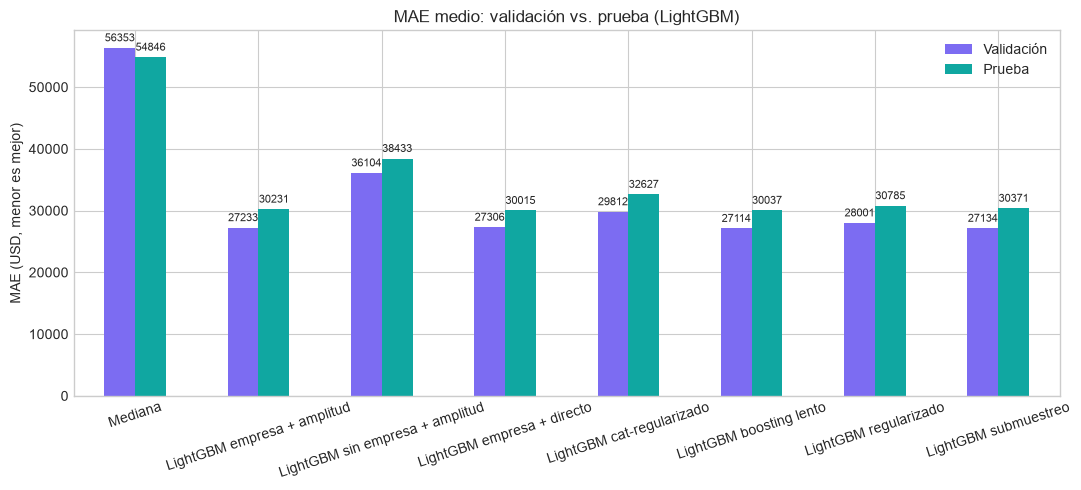

In [21]:
plt.style.use("seaborn-v0_8-whitegrid")
ax = experiment_table.set_index("experiment")[["validation_mae", "test_mae"]].plot(
    kind="bar", figsize=(11, 5), color=["#7c6cf2", "#10a7a1"])
ax.set(title="MAE medio: validación vs. prueba (LightGBM)", ylabel="MAE (USD, menor es mejor)", xlabel="")
ax.tick_params(axis="x", rotation=18); ax.legend(["Validación", "Prueba"])
for container in ax.containers: ax.bar_label(container, fmt="%.0f", padding=3, fontsize=8)
plt.tight_layout(); plt.show()


## 15. Ejemplo de salida que consumirá el frontend

In [18]:
example_index = metadata.loc[test_mask].index[0]
actual = metadata.loc[example_index]
position = list(metadata.loc[test_mask].index).index(example_index)
response = {
    "currency": "USD", "period": "year",
    "salary_min": round(float(test_predictions[0][position]), 2),
    "salary_max": round(float(test_predictions[1][position]), 2),
    "salary_midpoint": round(float((test_predictions[0][position] + test_predictions[1][position]) / 2), 2),
    "model_name": "lightgbm-reported-baseline", "run_id": run_id,
}
print(json.dumps(response, indent=2, ensure_ascii=False))
print("Valores reales reservados:", actual[["y_min_usd", "y_max_usd"]].to_dict())


{
  "currency": "USD",
  "period": "year",
  "salary_min": 98282.79,
  "salary_max": 131699.06,
  "salary_midpoint": 114990.92,
  "model_name": "lightgbm-reported-baseline",
  "run_id": "064cc1a427e64630abdc9199dfa4a963"
}
Valores reales reservados: {'y_min_usd': 125000.0, 'y_max_usd': 165000.0}


## 16. Próximos pasos

El notebook de CatBoost del equipo va más allá del baseline con los
experimentos B (alineación Reportado→Estimado), B.1 (distribution shift),
B.2 (alineación condicional a EE. UU.) y C (calibración por país). Esos son
análisis de generalización que no dependen de la familia de modelo — vale la
pena discutir con el equipo si conviene repetirlos aquí con LightGBM antes de
comparar formalmente ambos modelos, o si basta con correrlos una sola vez con
el modelo que gane en validación.

La sección 10 (generalización por empresa, vista/no vista) es una adición
propia, separada de la de CatBoost -- queda controlada por
`RUN_COMPANY_GENERALIZATION` / `evaluation.company_generalization.enabled`
en `params.yaml`, así que adoptarla (o no) como equipo, o reconciliarla con
la lógica equivalente de `catboost_colab.ipynb` (celda 36, sobre el split del
Experimento B en vez del split principal), es una decisión de configuración
pendiente, no un cambio de código.